# Sample size imbalance comparison

In [1]:
import pandas as pd

# Load the CSV file
rmse_res_intHTE = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_intHTE_results.csv")
rmse_res_causalICM = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_results.csv")
rmse_res_powerLik = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalanxe_powerLik_results.csv")


In [6]:
rmse_res_intHTE.columns

Index(['obs_sample_size', 'rep', 'rmse', 'bias', 'variance'], dtype='object')

In [9]:
rmse_res_causalICM.columns

Index(['obs_sample_size', 'rep', 'best_rho', 'rmse', 'bias', 'variance'], dtype='object')

In [10]:
rmse_res_powerLik.columns

Index(['obs_sample_size', 'datasetNo', 'rmse'], dtype='object')

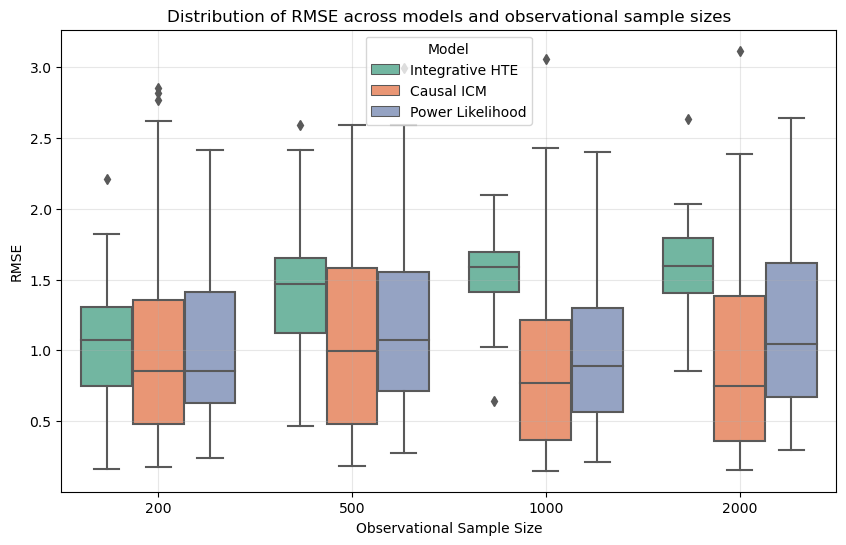

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSVs
rmse_res_intHTE = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_intHTE_results.csv")
rmse_res_causalICM = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_results.csv")
rmse_res_powerLik = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalanxe_powerLik_results.csv")

# Standardize column names and add 'model' column
df_intHTE = rmse_res_intHTE[['obs_sample_size', 'rmse']].copy()
df_intHTE['model'] = 'Integrative HTE'

df_causalICM = rmse_res_causalICM[['obs_sample_size', 'rmse']].copy()
df_causalICM['model'] = 'Causal ICM'

df_powerLik = rmse_res_powerLik[['obs_sample_size', 'rmse']].copy()
df_powerLik['model'] = 'Power Likelihood'

# Concatenate all into one DataFrame
df_all = pd.concat([df_intHTE, df_causalICM, df_powerLik], ignore_index=True)

# Optional: ensure 'obs_sample_size' is categorical for better plotting
df_all['obs_sample_size'] = df_all['obs_sample_size'].astype(str)

# Create the boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='obs_sample_size', y='rmse', hue='model', data=df_all, palette='Set2')
plt.xlabel("Observational Sample Size")
plt.ylabel("RMSE")
plt.title("Distribution of RMSE across models and observational sample sizes")
plt.legend(title='Model')
plt.grid(alpha=0.3)
plt.show()


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSVs
rmse_res_intHTE = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_intHTE_results.csv")
rmse_res_causalICM = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalance_results.csv")
rmse_res_powerLik = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/sample_size_imbalanxe_powerLik_results.csv")

# Standardize column names and add 'model' column
df_intHTE = rmse_res_intHTE[['obs_sample_size', 'rmse']].copy()
df_intHTE['model'] = 'intHTE'

df_causalICM = rmse_res_causalICM[['obs_sample_size', 'rmse']].copy()
df_causalICM['model'] = 'causalICM'

df_powerLik = rmse_res_powerLik[['obs_sample_size', 'rmse']].copy()
df_powerLik['model'] = 'powerLik'

# Concatenate all into one DataFrame
df_all = pd.concat([df_intHTE, df_causalICM, df_powerLik], ignore_index=True)

# Optional: ensure 'obs_sample_size' is categorical for plotting
df_all['obs_sample_size'] = df_all['obs_sample_size'].astype(str)

# ============================================================
# Compute mean RMSE for each model and sample size
# ============================================================
rmse_stats = df_all.groupby(['obs_sample_size', 'model'])['rmse'].agg(['mean', 'std']).reset_index()
rmse_stats.rename(columns={'mean': 'mean_rmse', 'std': 'sd_rmse'}, inplace=True)

# Print the results
print(rmse_stats)



   obs_sample_size      model  mean_rmse   sd_rmse
0             1000  causalICM   0.928559  0.695031
1             1000     intHTE   1.545547  0.303484
2             1000   powerLik   0.975282  0.506191
3              200  causalICM   1.078376  0.809747
4              200     intHTE   1.079581  0.441167
5              200   powerLik   1.023115  0.559307
6             2000  causalICM   0.933797  0.673739
7             2000     intHTE   1.576061  0.318147
8             2000   powerLik   1.160631  0.606258
9              500  causalICM   1.071102  0.651913
10             500     intHTE   1.406409  0.461434
11             500   powerLik   1.230796  0.666881


# Variance Bound

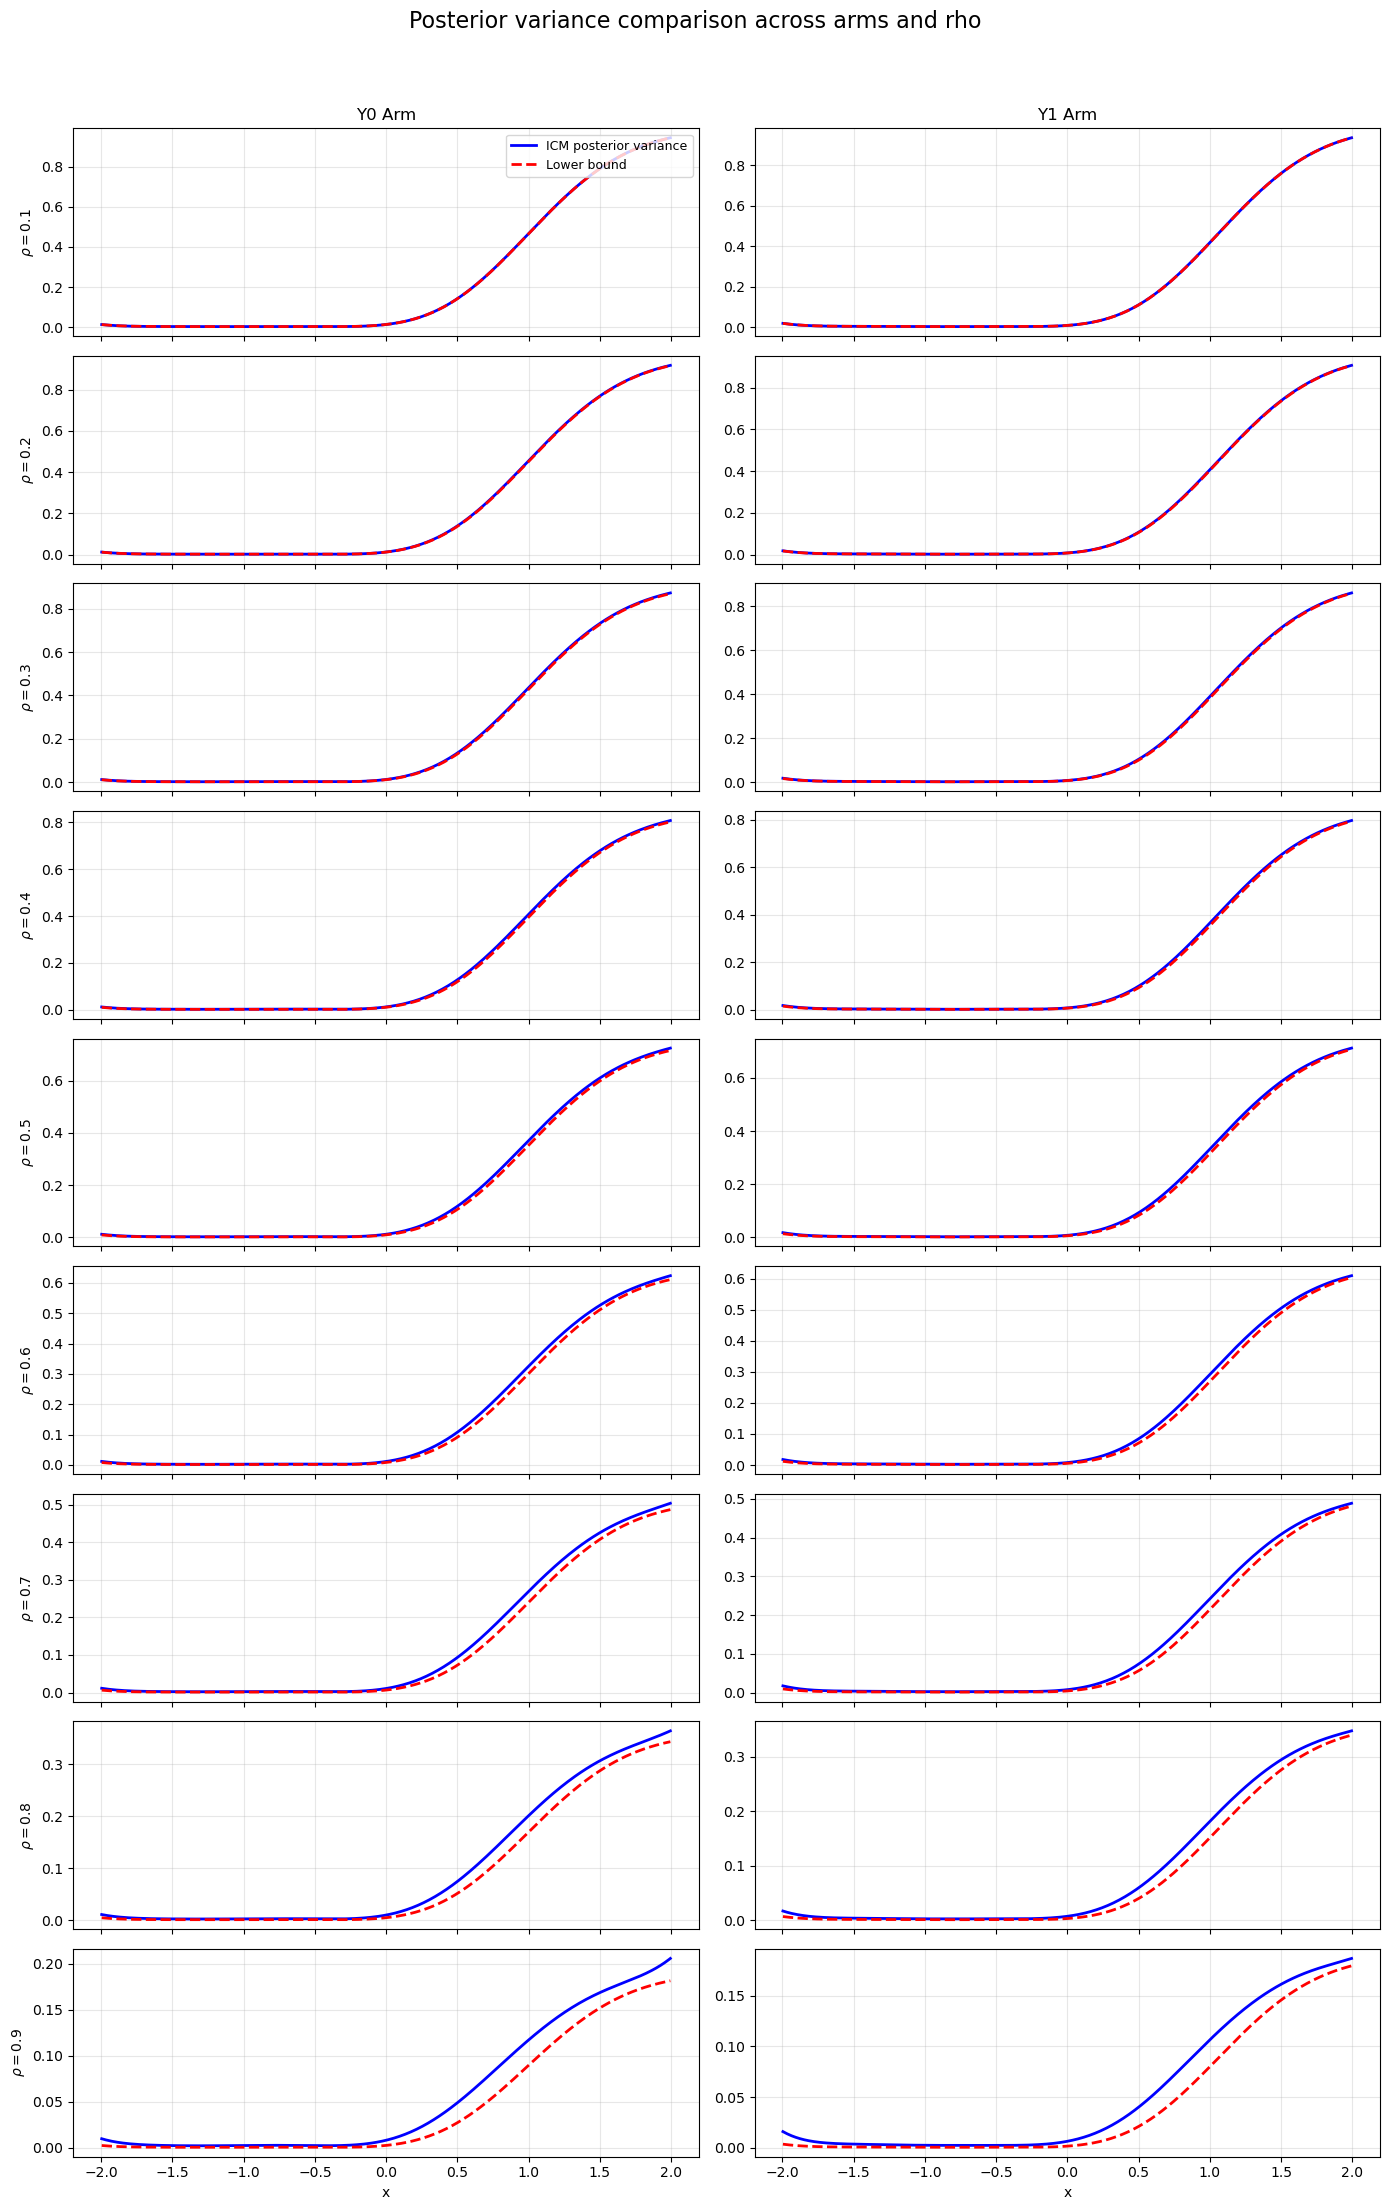

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ============================================================
# 1. Load the saved variance data
# ============================================================
df_Y0 = pd.read_csv("variance_bound_results_Y0.csv")
df_Y1 = pd.read_csv("variance_bound_results_Y1.csv")

# ============================================================
# 2. Define the list of rhos
# ============================================================
rhos = sorted(df_Y0['rho'].unique())
colors = cm.viridis(np.linspace(0, 1, len(rhos)))

# ============================================================
# 3. Create a single figure: rows=rhos, cols=2 (Y0, Y1)
# ============================================================
fig, axes = plt.subplots(len(rhos), 2, figsize=(14, 2.5*len(rhos)), sharex=True)

for i, rho in enumerate(rhos):
    # Y0 subplot
    ax0 = axes[i, 0] if len(rhos) > 1 else axes[0]
    df_rho_Y0 = df_Y0[df_Y0['rho'] == rho]
    ax0.plot(df_rho_Y0['x'], df_rho_Y0['ICM_var'], label="ICM posterior variance", color='blue', lw=2)
    ax0.plot(df_rho_Y0['x'], df_rho_Y0['scaled_exp_var'], label="Lower bound", color='red', lw=2, ls='--')
    ax0.set_ylabel(rf"$\rho={rho:.1f}$")
    ax0.grid(alpha=0.3)
    if i == 0:
        ax0.set_title("Y0 Arm")

    # Y1 subplot
    ax1 = axes[i, 1] if len(rhos) > 1 else axes[1]
    df_rho_Y1 = df_Y1[df_Y1['rho'] == rho]
    ax1.plot(df_rho_Y1['x'], df_rho_Y1['ICM_var'], label="ICM posterior variance", color='blue', lw=2)
    ax1.plot(df_rho_Y1['x'], df_rho_Y1['scaled_exp_var'], label="Lower bound", color='red', lw=2, ls='--')
    ax1.grid(alpha=0.3)
    if i == 0:
        ax1.set_title("Y1 Arm")

# Add legend only once (top-left)
axes[0,0].legend(loc='upper right', fontsize=9)

# Shared x-axis labels
for ax in axes[-1, :]:
    ax.set_xlabel("x")

fig.suptitle("Posterior variance comparison across arms and rho", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


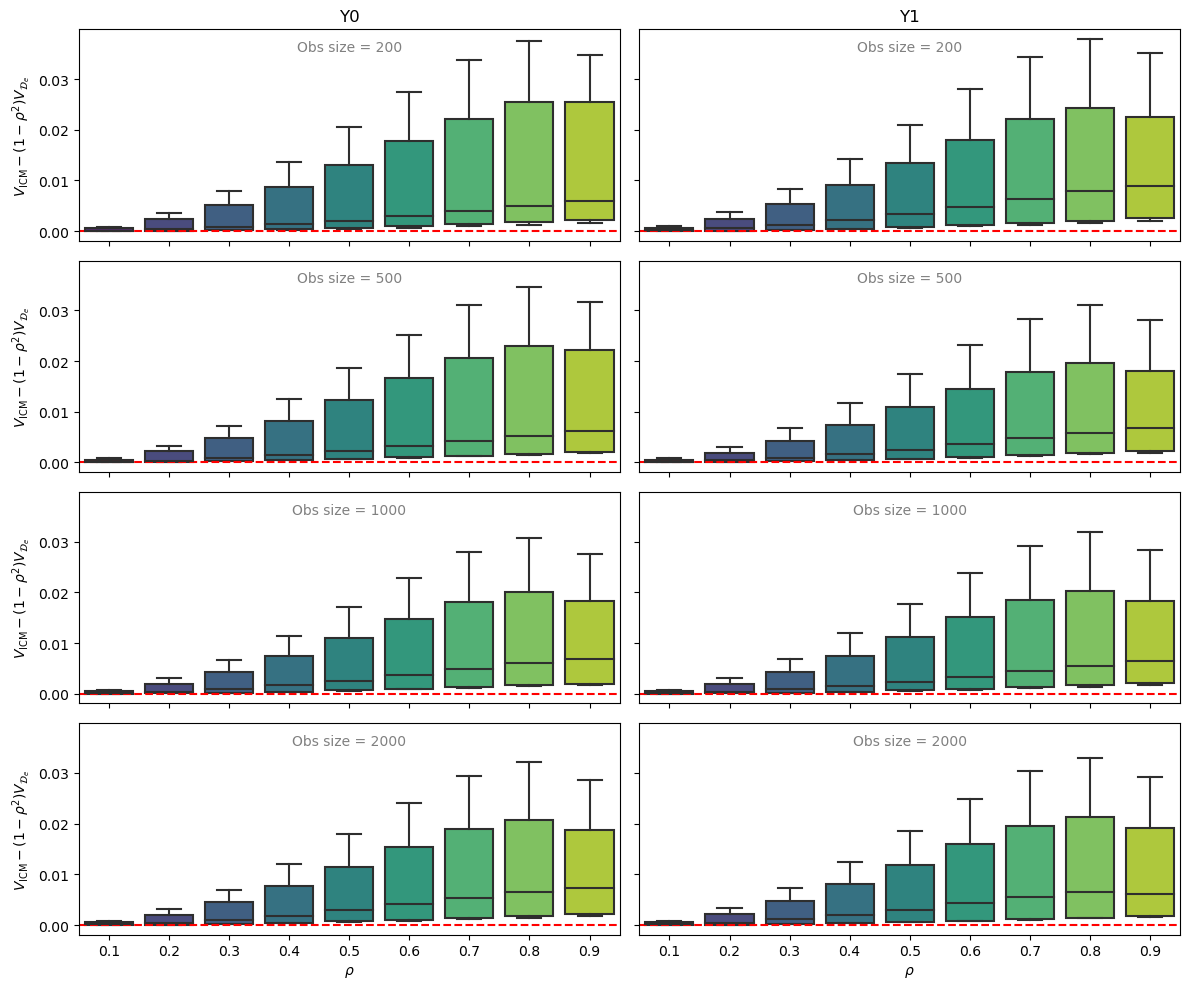

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Import the saved results
# -------------------------------
df_Y0_all = pd.read_csv("variance_bound_results_Y0_all_sample_sizes.csv")
df_Y1_all = pd.read_csv("variance_bound_results_Y1_all_sample_sizes.csv")

# -------------------------------
# 2. Compute variance difference
# V_Causal-ICM - (1-rho^2) V_exp
# -------------------------------
df_Y0_all['Variance_diff'] = df_Y0_all['ICM_var'] - df_Y0_all['scaled_exp_var']
df_Y1_all['Variance_diff'] = df_Y1_all['ICM_var'] - df_Y1_all['scaled_exp_var']

# Add Arm column for convenience
df_Y0_all['Arm'] = 'Y0'
df_Y1_all['Arm'] = 'Y1'

# Combine both arms
df_diff_all = pd.concat([df_Y0_all, df_Y1_all], ignore_index=True)

# -------------------------------
# 3. Plot boxplots
# -------------------------------
obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

# Ensure axes is 2D
if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]
        # Filter data for this obs size and arm
        df_plot = df_diff_all[(df_diff_all['obs_sample_size'] == obs_size) &
                              (df_diff_all['Arm'] == arm)]
        
        # Boxplot
        sns.boxplot(x='rho', y='Variance_diff', data=df_plot, palette="viridis", ax=ax)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)
        
        
        # Set x-ticks to the actual rho values
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 1)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.1f}" for r in unique_rhos])
        
        # Column title for arms
        if i == 0:
            ax.set_title(arm, fontsize=12)
        
        # Subtitle for obs size
        ax.text(0.5, 0.95, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')
        
        # Only bottom row has x-label
        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')
        
        # Only left column has y-label
        if j == 0:
            ax.set_ylabel(r"$V_{\mathrm{ICM}} - (1-\rho^2)V_{\mathcal{D}_e}$")
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()


/var/folders/9p/qrwxm32d31db34x1w56xp3_r0000gn/T/ipykernel_49276/4003371400.py:53: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  ax.axhline(0, color='red', linestyle='--', lw=1.5)
/var/folders/9p/qrwxm32d31db34x1w56xp3_r0000gn/T/ipykernel_49276/4003371400.py:53: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  ax.axhline(0, color='red', linestyle='--', lw=1.5)
/var/folders/9p/qrwxm32d31db34x1w56xp3_r0000gn/T/ipykernel_49276/4003371400.py:53: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  ax.axhline(0, color='red', linestyle='--', lw=1.5)
/var/folders/9p/qrwxm32d31db34x1w56xp3_r0000gn/T/ipykernel_49276/4003371400.py:53: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear

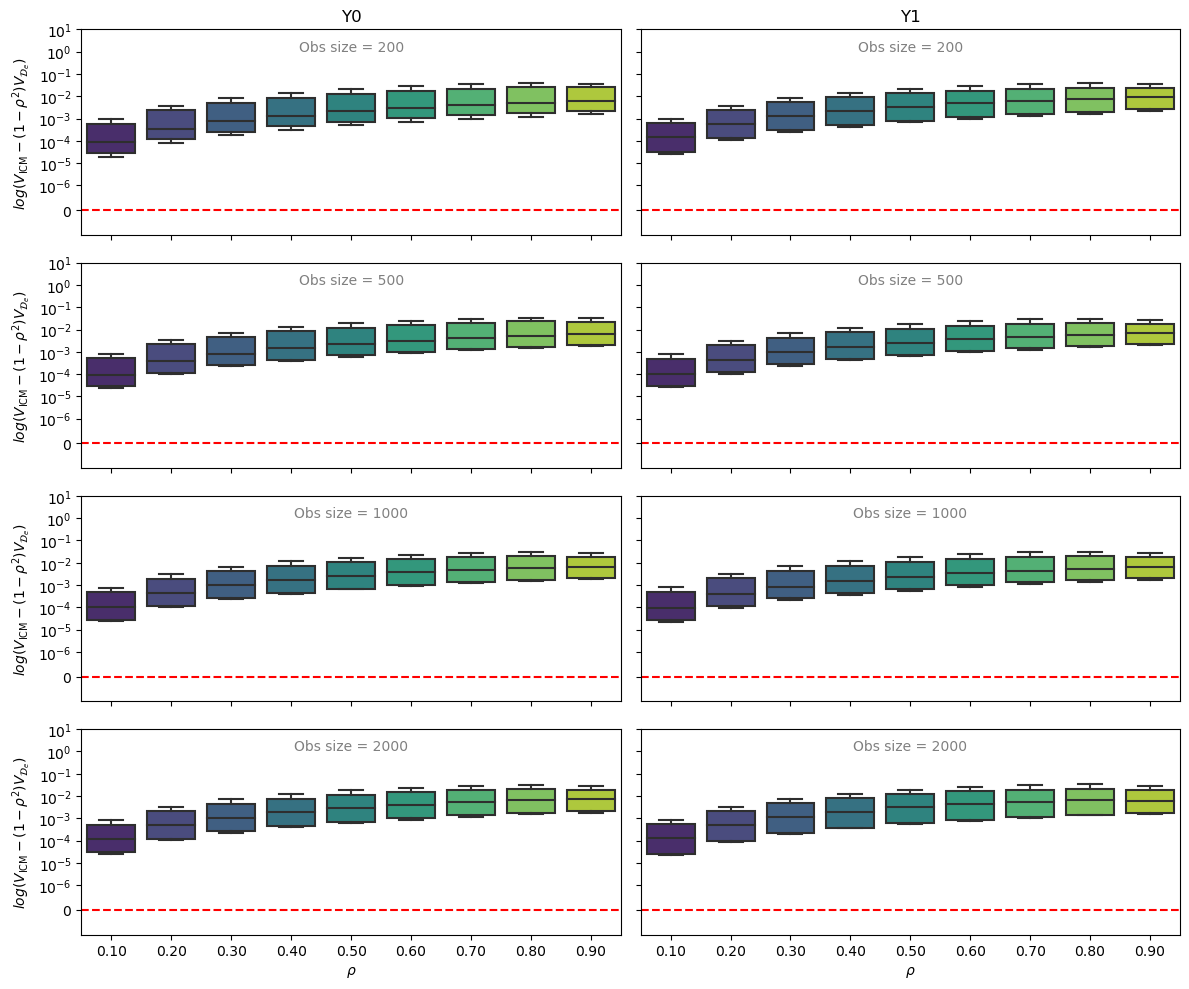

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Import the saved results
# -------------------------------
df_Y0_all = pd.read_csv("variance_bound_results_Y0_all_sample_sizes.csv")
df_Y1_all = pd.read_csv("variance_bound_results_Y1_all_sample_sizes.csv")

# -------------------------------
# 2. Compute variance difference
# V_Causal-ICM - (1-rho^2) V_exp
# -------------------------------
df_Y0_all['Variance_diff'] = df_Y0_all['ICM_var'] - df_Y0_all['scaled_exp_var']
df_Y1_all['Variance_diff'] = df_Y1_all['ICM_var'] - df_Y1_all['scaled_exp_var']

# Add Arm column
df_Y0_all['Arm'] = 'Y0'
df_Y1_all['Arm'] = 'Y1'

# Combine both arms
df_diff_all = pd.concat([df_Y0_all, df_Y1_all], ignore_index=True)


#print(f"Using linthresh = {linthresh:.3e}")

# -------------------------------
# 4. Plot boxplots with symlog scale
# -------------------------------
obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

# Ensure axes is 2D
if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]

        # Filter data
        df_plot = df_diff_all[(df_diff_all['obs_sample_size'] == obs_size) &
                              (df_diff_all['Arm'] == arm)]

        # Boxplot
        sns.boxplot(x='rho', y='Variance_diff', data=df_plot, palette="viridis", ax=ax)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)

        # Symmetric log scale (handles negative + zero values)
        ax.set_yscale("symlog", linthresh=1e-6)

        # Set x-ticks to actual rho values
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 2)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.2f}" for r in unique_rhos])
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(-0.000001, ymax * 2)

        # Column title for arms
        if i == 0:
            ax.set_title(arm, fontsize=12)

        # Subtitle for obs size
        ax.text(0.5, 0.95, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

        # Only bottom row has x-label
        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')

        # Only left column has y-label
        if j == 0:
            ax.set_ylabel(r"$log(V_{\mathrm{ICM}} - (1-\rho^2)V_{\mathcal{D}_e})$")
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()


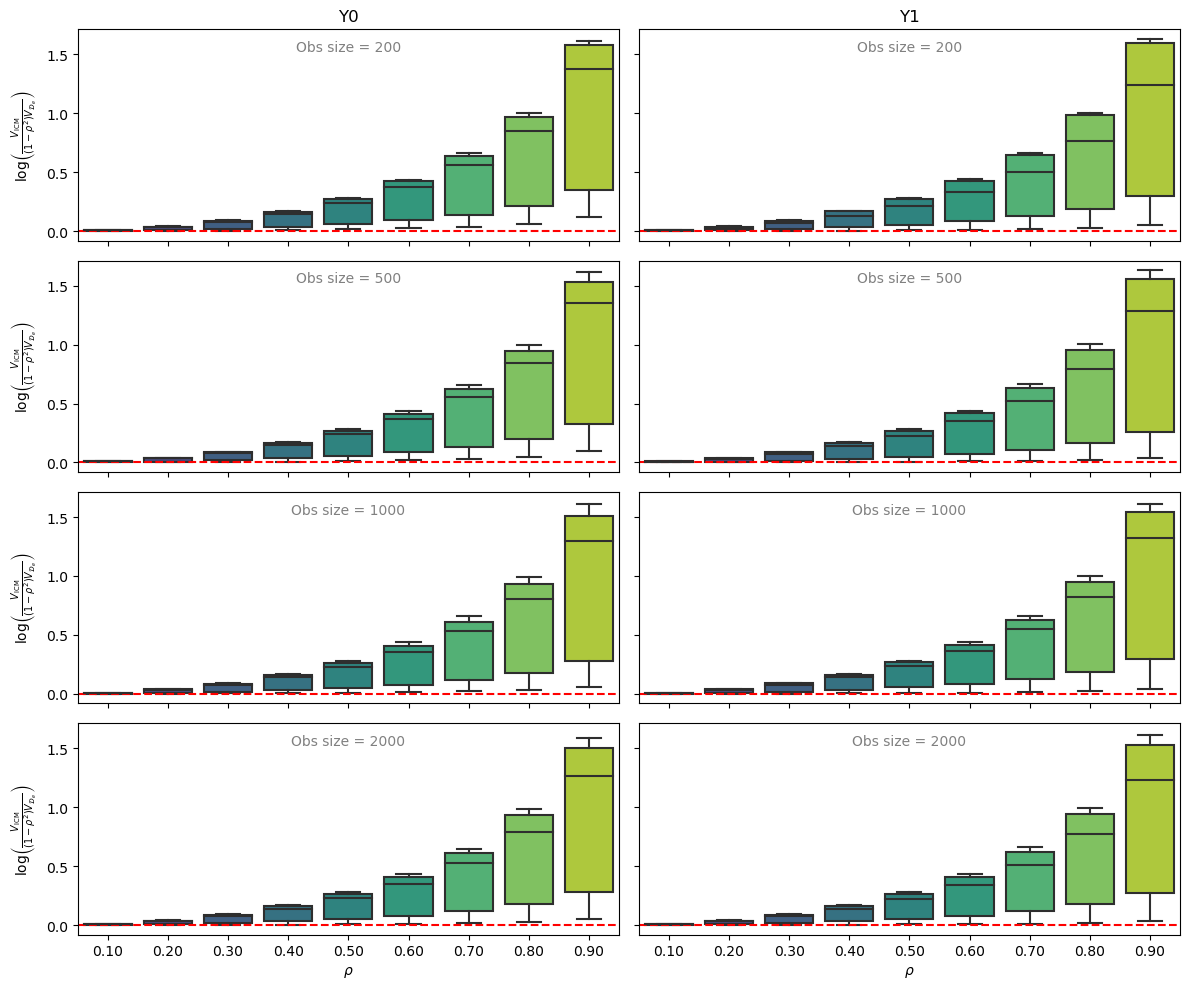

In [5]:
eps = 1e-12  # small constant to avoid division by zero / log(0)

df_Y0_all['log_ratio'] = np.log((df_Y0_all['ICM_var'] + eps) / (df_Y0_all['scaled_exp_var'] + eps))
df_Y1_all['log_ratio'] = np.log((df_Y1_all['ICM_var'] + eps) / (df_Y1_all['scaled_exp_var'] + eps))

df_Y0_all['Arm'] = 'Y0'
df_Y1_all['Arm'] = 'Y1'
df_diff_all = pd.concat([df_Y0_all, df_Y1_all], ignore_index=True)

obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]

        df_plot = df_diff_all[(df_diff_all['obs_sample_size'] == obs_size) &
                              (df_diff_all['Arm'] == arm)]

        sns.boxplot(x='rho', y='log_ratio', data=df_plot, palette="viridis", ax=ax)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)  # log ratio = 0 ⇔ ratio = 1

        # x-ticks
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 2)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.2f}" for r in unique_rhos])

        # Column title
        if i == 0:
            ax.set_title(arm, fontsize=12)

        # Subtitle
        ax.text(0.5, 0.95, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(r"$\log\!\left(\frac{V_{\mathrm{ICM}}}{(1-\rho^2)V_{\mathcal{D}_e}}\right)$")
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()


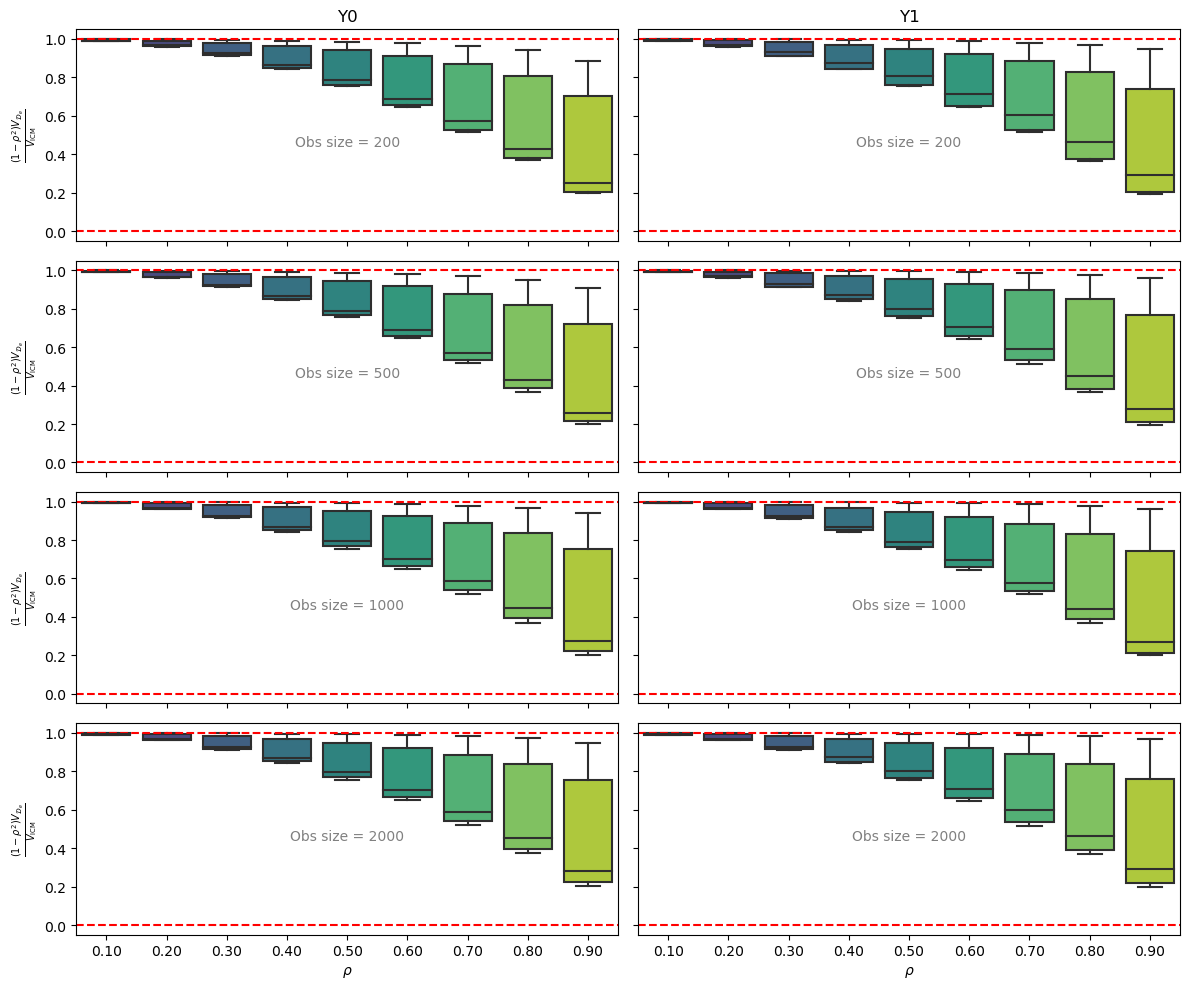

In [10]:
eps = 1e-12  # small constant to avoid division by zero / log(0)

df_Y0_all['log_ratio'] = (df_Y0_all['scaled_exp_var'] + eps)/(df_Y0_all['ICM_var'] + eps) 
df_Y1_all['log_ratio'] = (df_Y1_all['scaled_exp_var'] + eps)/(df_Y1_all['ICM_var'] + eps)

df_Y0_all['Arm'] = 'Y0'
df_Y1_all['Arm'] = 'Y1'
df_diff_all = pd.concat([df_Y0_all, df_Y1_all], ignore_index=True)

obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]

        df_plot = df_diff_all[(df_diff_all['obs_sample_size'] == obs_size) &
                              (df_diff_all['Arm'] == arm)]

        sns.boxplot(x='rho', y='log_ratio', data=df_plot, palette="viridis", ax=ax)
        ax.axhline(0, color='red', linestyle='--', lw=1.5)  # log ratio = 0 ⇔ ratio = 1
        ax.axhline(1, color='red', linestyle='--', lw=1.5)  # log ratio = 0 ⇔ ratio = 1

        # x-ticks
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 2)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.2f}" for r in unique_rhos])

        # Column title
        if i == 0:
            ax.set_title(arm, fontsize=12)

        # Subtitle
        ax.text(0.5, 0.5, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(r"$\frac{(1-\rho^2)V_{\mathcal{D}_e}}{V_{\mathrm{ICM}}}$")
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()


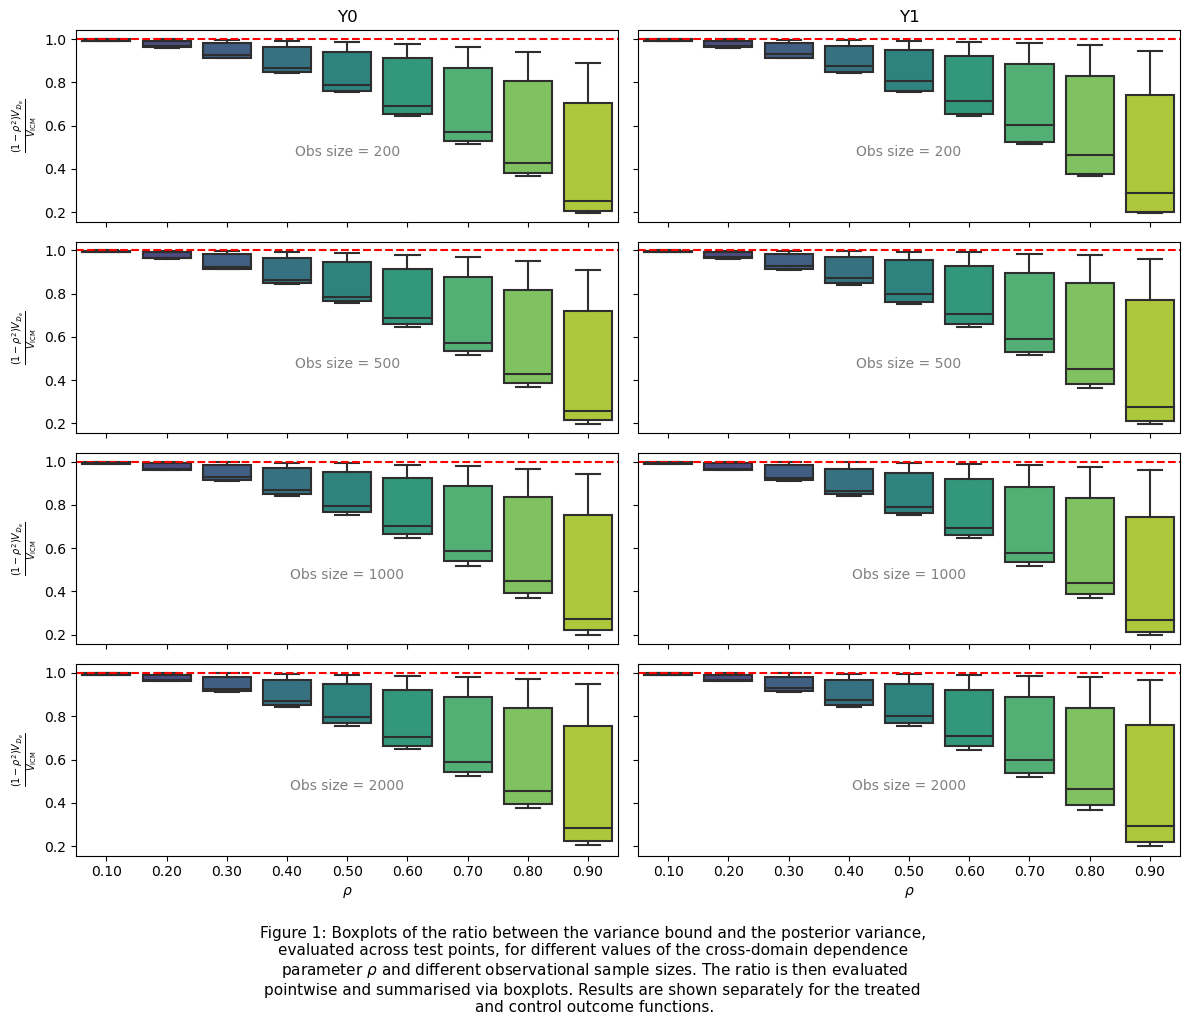

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

eps = 1e-12  # small constant to avoid division by zero

df_Y0_all['log_ratio'] = (df_Y0_all['scaled_exp_var'] + eps) / (df_Y0_all['ICM_var'] + eps)
df_Y1_all['log_ratio'] = (df_Y1_all['scaled_exp_var'] + eps) / (df_Y1_all['ICM_var'] + eps)

df_Y0_all['Arm'] = 'Y0'
df_Y1_all['Arm'] = 'Y1'
df_diff_all = pd.concat([df_Y0_all, df_Y1_all], ignore_index=True)

obs_sizes = [200, 500, 1000, 2000]
arms = ['Y0', 'Y1']

fig, axes = plt.subplots(len(obs_sizes), len(arms), figsize=(12, 10), sharey=True, sharex=True)

if len(obs_sizes) == 1:
    axes = axes[np.newaxis, :]
if len(arms) == 1:
    axes = axes[:, np.newaxis]

for j, arm in enumerate(arms):
    for i, obs_size in enumerate(obs_sizes):
        ax = axes[i, j]

        df_plot = df_diff_all[
            (df_diff_all['obs_sample_size'] == obs_size) &
            (df_diff_all['Arm'] == arm)
        ]

        sns.boxplot(x='rho', y='log_ratio', data=df_plot, palette="viridis", ax=ax)

        ax.axhline(1, color='red', linestyle='--', lw=1.5)  # ratio = 1

        # x-ticks
        unique_rhos = np.round(sorted(df_plot['rho'].unique()), 2)
        ax.set_xticks(range(len(unique_rhos)))
        ax.set_xticklabels([f"{r:.2f}" for r in unique_rhos])

        # Column title
        if i == 0:
            ax.set_title(arm, fontsize=12)

        # Subtitle
        ax.text(0.5, 0.4, f"Obs size = {obs_size}", transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

        if i == len(obs_sizes) - 1:
            ax.set_xlabel(r"$\rho$")
        else:
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(r"$\frac{(1-\rho^2)V_{\mathcal{D}_e}}{V_{\mathrm{ICM}}}$")
        else:
            ax.set_ylabel('')

# --------- CAPTION ---------
caption = (
    "Figure 1: Boxplots of the ratio between the variance bound and the posterior variance, \n"
    "evaluated across test points, for different values of the cross-domain dependence \n"
    "parameter $\\rho$ and different observational sample sizes. The ratio is then evaluated \n"
    "pointwise and summarised via boxplots. Results are shown separately for the treated \n"
    "and control outcome functions."
)

# Adjust layout to make space for caption
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, -0.02, caption, ha='center', va='bottom', fontsize=11)

plt.show()


In [27]:
# Load the CSVs
in_sample_res = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/in_sample_comparison_results.csv")
in_sample_res_intHTE = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/in_sample_intHTE_results.csv")


In [31]:
in_sample_res_intHTE.head()

,RMSE,Bias,Variance
0,0.334872,-0.146878,0.923778
1,0.270726,0.066525,0.697116
2,0.209310,-0.044633,0.536074
3,0.157758,-0.029179,0.633779
4,0.496799,-0.331104,0.299434


In [32]:
in_sample_rmse_GP_exp = in_sample_res["RMSE_naiveGPexp"]
in_sample_rmse_GP_obs = in_sample_res["RMSE_naiveGPobs"]
in_sample_rmse_kallusGP = in_sample_res["RMSE_KallusGP"]
in_sample_rmse_causalICM = in_sample_res["RMSE_ICM"]
in_sample_rmse_intHTE = in_sample_res_intHTE["RMSE"]

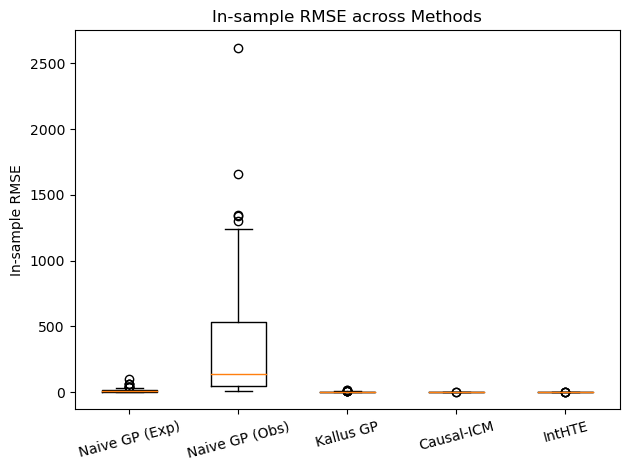

In [33]:
import matplotlib.pyplot as plt

# Collect RMSE arrays
data = [
    in_sample_res["RMSE_naiveGPexp"],
    in_sample_res["RMSE_naiveGPobs"],
    in_sample_res["RMSE_KallusGP"],
    in_sample_res["RMSE_ICM"],
    in_sample_res_intHTE["RMSE"]
]

labels = [
    "Naive GP (Exp)",
    "Naive GP (Obs)",
    "Kallus GP",
    "Causal-ICM",
    "IntHTE"
]

plt.figure()
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylabel("In-sample RMSE")
plt.title("In-sample RMSE across Methods")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [34]:
import numpy as np

mean_rmse_GP_exp = np.mean(in_sample_res["RMSE_naiveGPexp"])
mean_rmse_GP_obs = np.mean(in_sample_res["RMSE_naiveGPobs"])
mean_rmse_kallusGP = np.mean(in_sample_res["RMSE_KallusGP"])
mean_rmse_causalICM = np.mean(in_sample_res["RMSE_ICM"])
mean_rmse_intHTE = np.mean(in_sample_res_intHTE["RMSE"])

print("Naive GP (Exp):", mean_rmse_GP_exp)
print("Naive GP (Obs):", mean_rmse_GP_obs)
print("Kallus GP:", mean_rmse_kallusGP)
print("Causal-ICM:", mean_rmse_causalICM)
print("IntHTE:", mean_rmse_intHTE)


Naive GP (Exp): 15.301950260413117
Naive GP (Obs): 343.386670783223
Kallus GP: 3.0476547724354175
Causal-ICM: 0.2521729217659506
IntHTE: 0.30741501573259356


In [35]:
import numpy as np

sd_rmse_GP_exp = np.std(in_sample_res["RMSE_naiveGPexp"])
sd_rmse_GP_obs = np.std(in_sample_res["RMSE_naiveGPobs"])
sd_rmse_kallusGP = np.std(in_sample_res["RMSE_KallusGP"])
sd_rmse_causalICM = np.std(in_sample_res["RMSE_ICM"])
sd_rmse_intHTE = np.std(in_sample_res_intHTE["RMSE"])

print("Naive GP (Exp):", sd_rmse_GP_exp)
print("Naive GP (Obs):", sd_rmse_GP_obs)
print("Kallus GP:", sd_rmse_kallusGP)
print("Causal-ICM:", sd_rmse_causalICM)
print("IntHTE:", sd_rmse_intHTE)


Naive GP (Exp): 15.594969166902686
Naive GP (Obs): 436.31842138839886
Kallus GP: 3.1412778547150846
Causal-ICM: 0.09927168094410194
IntHTE: 0.11443748500274957


# Out of sample performance

In [5]:
# Load the CSVs
import pandas as pd
out_of_sample_res = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/out_of_sample_comparison_results.csv")
out_of_sample_res_intHTE = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/out_sample_intHTE_results.csv")


In [6]:
import numpy as np

mean_rmse_GP_exp = np.mean(out_of_sample_res["RMSE_naiveGPexp"])
mean_rmse_GP_obs = np.mean(out_of_sample_res["RMSE_naiveGPobs"])
mean_rmse_kallusGP = np.mean(out_of_sample_res["RMSE_KallusGP"])
mean_rmse_causalICM = np.mean(out_of_sample_res["RMSE_ICM"])
mean_rmse_intHTE = np.mean(out_of_sample_res_intHTE["RMSE"])
print("Naive GP (Exp):", mean_rmse_GP_exp)
print("Naive GP (Obs):", mean_rmse_GP_obs)
print("Kallus GP:", mean_rmse_kallusGP)
print("Causal-ICM:", mean_rmse_causalICM)
print("IntHTE:", mean_rmse_intHTE)

import numpy as np

sd_rmse_GP_exp = np.std(out_of_sample_res["RMSE_naiveGPexp"])
sd_rmse_GP_obs = np.std(out_of_sample_res["RMSE_naiveGPobs"])
sd_rmse_kallusGP = np.std(out_of_sample_res["RMSE_KallusGP"])
sd_rmse_causalICM = np.std(out_of_sample_res["RMSE_ICM"])
sd_rmse_intHTE = np.std(out_of_sample_res_intHTE["RMSE"])

print("Naive GP (Exp):", sd_rmse_GP_exp)
print("Naive GP (Obs):", sd_rmse_GP_obs)
print("Kallus GP:", sd_rmse_kallusGP)
print("Causal-ICM:", sd_rmse_causalICM)
print("IntHTE:", sd_rmse_intHTE)


Naive GP (Exp): 9.6446022909034
Naive GP (Obs): 310.8230199337655
Kallus GP: 43.46065769160247
Causal-ICM: 1.0712071472736866
IntHTE: 3.15334858283599
Naive GP (Exp): 13.259397959448298
Naive GP (Obs): 412.96450055846213
Kallus GP: 42.069120530120735
Causal-ICM: 0.7215434695396852
IntHTE: 0.9190224030792882


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSVs
intHTE_mod_comp_multi_linear_df = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/intHTE_mod_comp_linear.csv")


In [10]:
intHTE_mod_comp_multi_linear_df["RMSE"].mean()

21.882686232268284

In [12]:
intHTE_mod_comp_multi_linear_df["RMSE"].std()

3.33008419316304

In [23]:
import pandas as pd
sim4_modelComp = pd.read_csv('/Users/evangelosdimitriou/myGitRepo/multi-task-GPs-for-Treatment-Effect-Estimation-2/__pycache__/neurIPS/multivariate/Simulation 4/sim4_modelComparison.csv')
sim4_modelComp_shuYang = pd.read_csv("/Users/evangelosdimitriou/myGitRepo/CausalICM/CLeaR/rebuttals/intHTE_mod_comp_linear.csv")

In [24]:
import numpy as np
mean_rmse_GP_exp = np.mean(sim4_modelComp["RMSE_naiveGPexp"])
mean_rmse_GP_obs = np.mean(sim4_modelComp["RMSE_naiveGPobs"])
mean_rmse_kallusGP = np.mean(sim4_modelComp["RMSE_KallusGP"])
mean_rmse_causalICM = np.mean(sim4_modelComp["RMSE_ICM"])
mean_rmse_intHTE = np.mean(sim4_modelComp_shuYang["RMSE"])
print("Naive GP (Exp):", mean_rmse_GP_exp)
print("Naive GP (Obs):", mean_rmse_GP_obs)
print("Kallus GP:", mean_rmse_kallusGP)
print("Causal-ICM:", mean_rmse_causalICM)
print("IntHTE:", mean_rmse_intHTE)

import numpy as np

sd_rmse_GP_exp = np.std(sim4_modelComp["RMSE_naiveGPexp"])
sd_rmse_GP_obs = np.std(sim4_modelComp["RMSE_naiveGPobs"])
sd_rmse_kallusGP = np.std(sim4_modelComp["RMSE_KallusGP"])
sd_rmse_causalICM = np.std(sim4_modelComp["RMSE_ICM"])
sd_rmse_intHTE = np.std(sim4_modelComp_shuYang["RMSE"])

print("Naive GP (Exp):", sd_rmse_GP_exp)
print("Naive GP (Obs):", sd_rmse_GP_obs)
print("Kallus GP:", sd_rmse_kallusGP)
print("Causal-ICM:", sd_rmse_causalICM)
print("IntHTE:", sd_rmse_intHTE)

Naive GP (Exp): 3.4216107868152013
Naive GP (Obs): 3.5802013080138018
Kallus GP: 3.5823313932104583
Causal-ICM: 2.5863073713601863
IntHTE: 21.882686232268284
Naive GP (Exp): 2.1860374032610035
Naive GP (Obs): 0.7960418068237918
Kallus GP: 1.713842251445918
Causal-ICM: 1.5130745612342529
IntHTE: 3.3133919367045594
